In [2]:
import torch
import torch.nn as nn
from monai.networks.nets import AutoEncoder
from easydict import EasyDict as edict
import json

In [3]:
with open("config/pipeline_test.json", "r") as f:
    cfg = edict(json.load(f))

In [4]:
model = AutoEncoder(
spatial_dims=2,                     # 3 for volumetric 3D (Conv3d / BatchNorm3d)
in_channels=1,                      # Input channels (monai.AutoEncoder takes int, not in_shape tuple)
out_channels=1,                     # Output channels
channels=(16, 32, 64, 128, 256),    # Feature map channels across downsampling stages
strides=(2, 2, 2, 2, 2),            # Stride of 2 at each stage (128 -> 64 -> 32 -> 16 -> 8 -> 4)
kernel_size=3,
up_kernel_size=3,
num_res_units=2,                    # Number of residual units per block
act="LEAKYRELU",
norm="BATCH",
dropout=0.1,
).to(cfg.device)

In [7]:
checkpoint = torch.load('reports/model_best.pth')
model.load_state_dict(checkpoint['model'])

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


<All keys matched successfully>

In [10]:
from dataset import get_dataloader

train_loader, _ = get_dataloader(cfg)
for data in train_loader:
    img = data['im']



total number of images: 20
number of images for training: 16
number of images for validation: 4
Running test


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [11]:
recon = model(img)

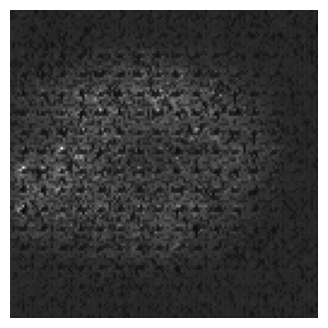

In [16]:
import matplotlib.pyplot as plt

# Assuming 'tensor_img' has shape torch.Size([1, 1, 128, 128])
img_2d = recon.detach().cpu().squeeze().numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_2d, cmap="gray")
plt.axis("off")
plt.show()